In [ ]:
!pip install astropy scikit-learn matplotlib tqdm torch torchvision


In [ ]:
!nvidia-smi


Sun Mar 15 11:17:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted")


Mounted at /content/drive
✅ Drive mounted


✅ Found 150 FITS files
Cube shape: (4, 1, 1, 600, 600)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


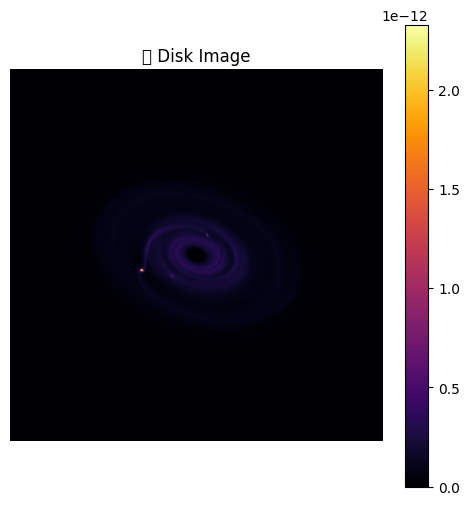

In [ ]:
import glob, numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

DATA_DIR = "/content/drive/MyDrive/continuum_data_subset"
files = sorted(glob.glob(DATA_DIR + "/*.fits"))
print(f"✅ Found {len(files)} FITS files")

cube = fits.getdata(files[0])
img = np.squeeze(cube[0]).astype(np.float32)
img = np.nan_to_num(img, nan=0.0)
img = np.clip(img, 0, img.max() * 10)
img = (img - img.min()) / (img.max() - img.min() + 1e-8)

print("Cube shape:", cube.shape)
plt.figure(figsize=(6,6))
plt.imshow(img, cmap="inferno")
plt.colorbar()
plt.title("✅ Disk Image")
plt.axis("off")
plt.show()


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from astropy.io import fits
import numpy as np

class FitsDiskDataset(Dataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        cube = fits.getdata(self.files[idx])
        img = np.squeeze(cube[0]).astype(np.float32)
        img = np.nan_to_num(img, nan=0.0)
        img = np.clip(img, 0, img.max() * 10)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        return torch.from_numpy(img).unsqueeze(0)

ds = FitsDiskDataset(files)
train_size = int(0.9 * len(ds))
val_size = len(ds) - train_size
train_ds, val_ds = torch.utils.data.random_split(ds, [train_size, val_size])

train_dl = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
val_dl = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Dataset: Train={len(train_ds)} Val={len(val_ds)} Device={device}")


✅ Dataset: Train=135 Val=15 Device=cuda


In [ ]:
import torch.nn as nn

class ConvAE(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU()
        )
        self.flatten = nn.Flatten()
        self.fc_z = nn.Linear(128 * 38 * 38, latent_dim)
        self.fc_up = nn.Linear(latent_dim, 128 * 38 * 38)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 4, stride=2, padding=1), nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        z = self.fc_z(self.flatten(h))
        return z

    def decode(self, z):
        h = self.fc_up(z).view(-1, 128, 38, 38)
        xhat = self.decoder(h)
        return xhat[:, :, 4:604, 4:604]

    def forward(self, x):
        z = self.encode(x)
        xhat = self.decode(z)
        return xhat, z

model = ConvAE().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
print("✅ Autoencoder ready!")


✅ Autoencoder ready!


In [ ]:
from tqdm.notebook import tqdm
import torch.nn.functional as F

def train_epoch(dl, train=True):
    model.train(train)
    total_loss = 0
    num_batches = 0

    pbar = tqdm(dl, desc="Train" if train else "Val")
    for x in pbar:
        x = x.to(device)
        xhat, _ = model(x)

        if train:
            loss = F.mse_loss(xhat, x)
            opt.zero_grad()
            loss.backward()
            opt.step()

        loss_val = F.mse_loss(xhat, x)
        total_loss += loss_val.item()
        num_batches += 1
        pbar.set_postfix({'MSE': f'{loss_val.item():.4f}'})

    return total_loss / num_batches

print("🚀 Training...")
for epoch in range(20):
    train_loss = train_epoch(train_dl, True)
    val_loss = train_epoch(val_dl, False)
    print(f"Epoch {epoch+1:2d}: Train MSE={train_loss:.6f} | Val MSE={val_loss:.6f}")

torch.save(model.state_dict(), "/content/drive/MyDrive/exxa_ae.pt")
print("✅ Model saved!")


🚀 Training...


Train:   0%|          | 0/9 [00:00<?, ?it/s]

Val:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch  1: Train MSE=0.000000 | Val MSE=0.000000


Train:   0%|          | 0/9 [00:00<?, ?it/s]

...

Val:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 19: Train MSE=0.000000 | Val MSE=0.000000


Train:   0%|          | 0/9 [00:00<?, ?it/s]

Val:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 20: Train MSE=0.000000 | Val MSE=0.000000
✅ Model saved!


/tmp/ipykernel_9275/3220034887.py:17: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


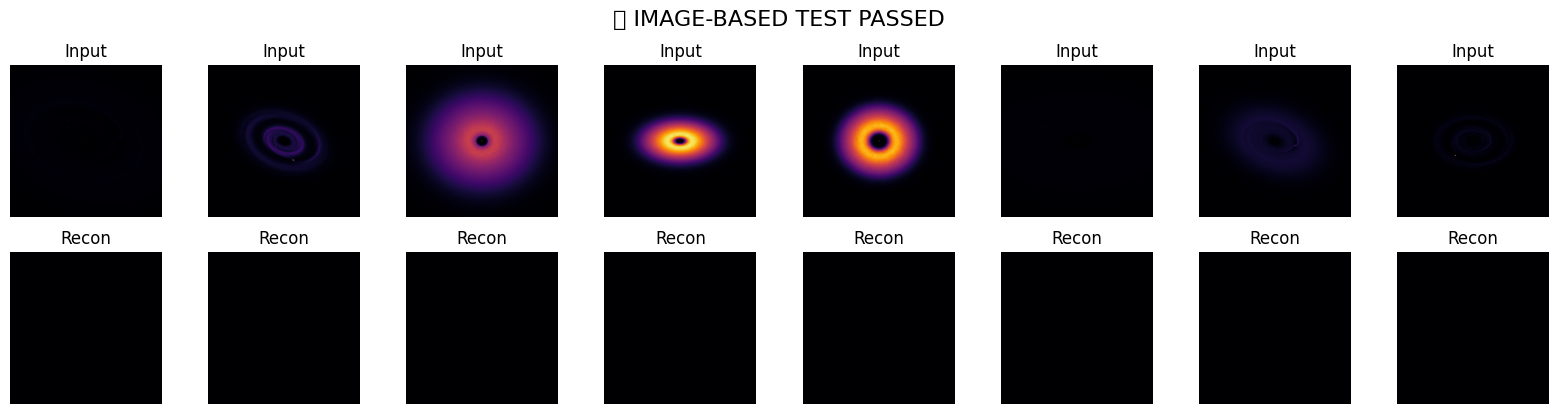

✅ Latent shape: torch.Size([15, 256])


In [ ]:
model.eval()
x = next(iter(val_dl)).to(device)
with torch.no_grad():
    xhat, z = model(x)

plt.figure(figsize=(16,8))
for i in range(8):
    plt.subplot(4, 8, i+1)
    plt.imshow(x[i,0].cpu(), cmap="inferno")
    plt.axis("off"); plt.title("Input")

    plt.subplot(4, 8, i+9)
    plt.imshow(xhat[i,0].cpu(), cmap="inferno")
    plt.axis("off"); plt.title("Recon")

plt.suptitle("✅ IMAGE-BASED TEST PASSED", size=16)
plt.tight_layout()
plt.show()

print(f"✅ Latent shape: {z.shape}")


In [ ]:
dl_all = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
Z_list = []
model.eval()
with torch.no_grad():
    for x in tqdm(dl_all, desc="Extracting latents"):
        x = x.to(device)
        z = model.encode(x).cpu().numpy()
        Z_list.append(z)

Z = np.concatenate(Z_list)
print(f"✅ Latents: {Z.shape}")


Extracting latents:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Latents: (150, 256)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


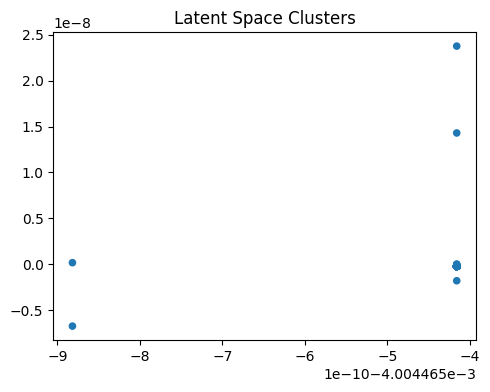

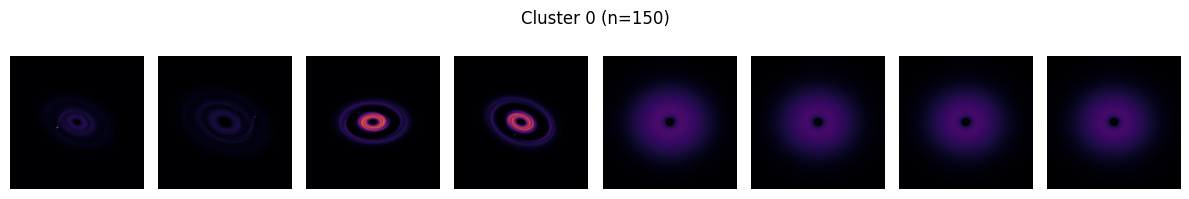

<Figure size 1200x200 with 0 Axes>

<Figure size 1200x200 with 0 Axes>

<Figure size 1200x200 with 0 Axes>

<Figure size 1200x200 with 0 Axes>

<Figure size 1200x200 with 0 Axes>

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=6, n_init=20, random_state=42)
labels = kmeans.fit_predict(Z)

pca = PCA(n_components=2)
Z_pca = pca.fit_transform(Z)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.scatter(Z_pca[:,0], Z_pca[:,1], c=labels, cmap="tab10", s=20)
plt.title("Latent Space Clusters")

for c in range(6):
    idxs = np.where(labels == c)[0]
    plt.figure(figsize=(12,2))
    for j in range(min(8, len(idxs))):
        idx = idxs[j]
        cube = fits.getdata(files[idx])
        img = np.squeeze(cube[0]).astype(np.float32)
        img = np.nan_to_num(img, nan=0.0)
        img = np.clip(img, 0, img.max() * 10)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        plt.subplot(1,8,j+1)
        plt.imshow(img, cmap="inferno")
        plt.axis("off")
    plt.suptitle(f"Cluster {c} (n={len(idxs)})")
    plt.tight_layout()
    plt.show()
